In the following we will fit a simple two layer BNN to ou wine dataset

Let us first import the necessary libraries. Note that as of Version 5 PyMC should be used with PyTensor and neither Theano or Aesara.

In [7]:
import pymc as pm
import pandas as pd
import numpy as np
import pytensor.tensor as pt

In [8]:
print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v5.15.1


In [9]:
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_wine

Next let us import our data and perform some pre-scaling.

In [10]:
# Load Data
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target)


# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to numpy arrays
X_scaled = X_scaled.astype(np.float32)
y = y.astype(np.float32)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=SEED)

Next we fit a BNN with PyMC.The syntax is similar to pytorch and can be looked up at the packages webpage which provides some documentation. Since MCMC methods are opften more time consuming than Variational Methods, let's go for the latter one.

In [11]:
# set up a simple 2 hidden layer BNN
with pm.Model() as model:

    X_input = pm.Data("X_input", X_train)
    
    # first layer
    w_layer_1 = pm.Normal("w_1", mu=0, sigma=1, shape=(X_train.shape[1],10))
    b_layer_1 = pm.Normal("b_in_1", mu=0, sigma=1, shape=(10, ))
    layer_1 = pt.tanh(pt.dot(X_input, w_layer_1) + b_layer_1)
    
    # second layer (=output layer)
    w_layer_2 = pm.Normal("w_2", mu=0, sigma=1, shape=(10, 1))
    b_layer_2 = pm.Normal("b_2", mu = 0, sigma=1, shape=(10,))
    out = pt.dot(layer_1, w_layer_2) + b_layer_2
    
    # Set up the Likelihood
    y_obs = pm.Normal("y_obs", mu=out, sigma=1, 
                      # shape needs to be adjusted
                      observed=y_train.values.reshape(-1, 1))
    
    # Variational Inference setup (Automatic Differentiation Variational Inference)
    mean_field = pm.fit(method="advi", n=20000)

Output()

Finished [100%]: Average Loss = 1,465


Having fitted out BNN we want to sample from the posterior.

In [12]:
# Sampling from the posterior
with model:
    trace = mean_field.sample(1000)

... and show some results:

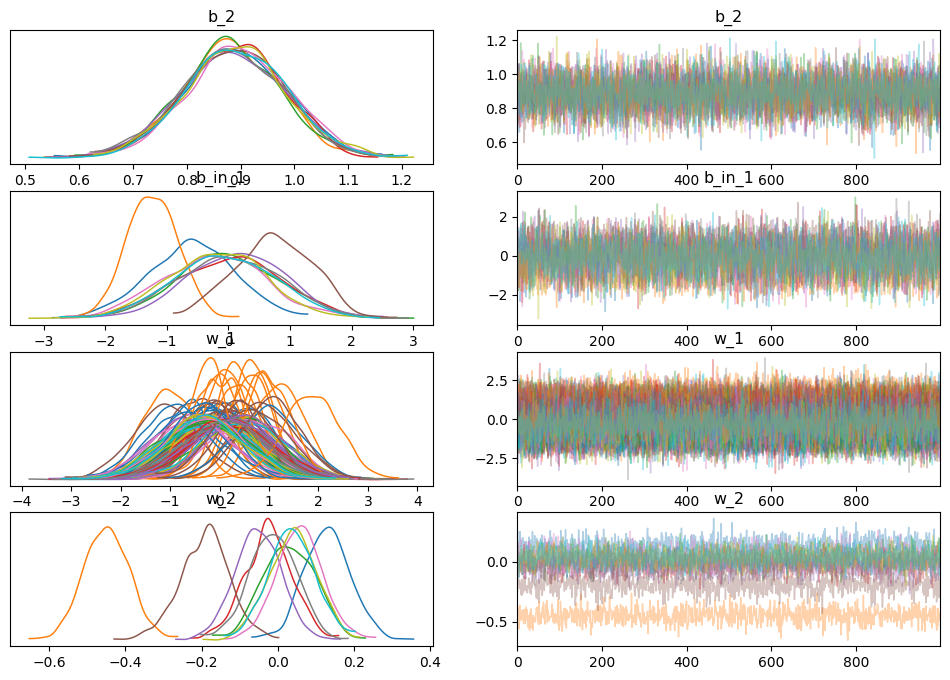

In [13]:
_ = pm.plot_trace(trace)

In [14]:
# Posterior predictive check
with model:
    pm.set_data({"X_input": X_test})
    posterior_predictive = pm.sample_posterior_predictive(trace, var_names=["y_obs"])

Sampling: [y_obs]


Output()

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (142, 1) and arg 1 with shape (36, 10).
Apply node that caused the error: normal_rv{0, (0, 0), floatX, True}(RandomGeneratorSharedVariable(<Generator(PCG64) at 0x7FED2459EEA0>), [142   1], 11, Add.0, 1)
Toposort index: 10
Inputs types: [RandomGeneratorType, TensorType(int64, shape=(2,)), TensorType(int64, shape=()), TensorType(float64, shape=(None, 10)), TensorType(int8, shape=())]
Inputs shapes: ['No shapes', (2,), (), (36, 10), ()]
Inputs strides: ['No strides', (8,), (), (80, 8), ()]
Inputs values: [Generator(PCG64) at 0x7FED2459EEA0, array([142,   1]), array(11), 'not shown', array(1, dtype=int8)]
Outputs clients: [['output'], ['output']]

HINT: Re-running with most PyTensor optimizations disabled could provide a back-trace showing when this node was created. This can be done by setting the PyTensor flag 'optimizer=fast_compile'. If that does not work, PyTensor optimizat